# English–Bangla Transformer from Scratch (~22.6M Parameters)

This notebook loads Drive-saved 128D embeddings and tokenized splits, projects embeddings to `d_model=512`, adds sinusoidal positional encoding inside the model, builds the Encoder, Decoder, and Transformer from scratch, then trains, validates, tests, and saves metrics and checkpoints.

> This stage converts token IDs into dense vectors so the Transformer can work with numerical representations of words.

## Imports

Imports configuration, data, modeling, plotting, and evaluation utilities.

> This cell prepares the libraries and environment needed to build and train the Transformer.

In [1]:
import json
import math
import random
import re
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

## — Mount Google Drive

Connects Colab to the saved tokenization, embeddings, and model-output folders.

> This stage converts token IDs into dense vectors so the Transformer can work with numerical representations of words.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## — Configuration

Defines a balanced 3-layer Encoder and 3-layer Decoder with about 22.6M parameters.

> These settings define the Transformer’s capacity and training behavior, such as hidden size, number of layers, attention heads, and dropout.

In [3]:
@dataclass
class TransformerConfig:
    drive_root: str = "/content/drive/MyDrive/Transformer"
    tokenized_folder: str = "tokenized_data"
    embedding_folder: str = "trained_embeddings"
    output_folder: str = "transformer_22m"

    pretrained_embedding_dimension: int = 128
    model_dimension: int = 512
    number_of_heads: int = 8
    encoder_layers: int = 3
    decoder_layers: int = 3
    feedforward_dimension: int = 2048
    dropout: float = 0.10
    max_sequence_length: int = 32

    batch_size: int = 32
    epochs: int = 30
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    gradient_clip: float = 1.0
    label_smoothing: float = 0.10
    early_stopping_patience: int = 6
    num_workers: int = 0
    random_seed: int = 42

    padding_id: int = 0
    unknown_id: int = 1
    beginning_id: int = 2
    end_id: int = 3


config = TransformerConfig()

if config.model_dimension % config.number_of_heads != 0:
    raise ValueError("model_dimension must be divisible by number_of_heads.")

random.seed(config.random_seed)
torch.manual_seed(config.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drive_root = Path(config.drive_root)
tokenized_dir = drive_root / config.tokenized_folder
embedding_dir = (
    drive_root
    / config.embedding_folder
    / f"{config.pretrained_embedding_dimension}d"
)
output_dir = drive_root / config.output_folder
output_dir.mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("Tokenized data:", tokenized_dir)
print("Pretrained embeddings:", embedding_dir)
print("Outputs:", output_dir)

Device: cuda
Tokenized data: /content/drive/MyDrive/Transformer/tokenized_data
Pretrained embeddings: /content/drive/MyDrive/Transformer/trained_embeddings/128d
Outputs: /content/drive/MyDrive/Transformer/transformer_22m


## — Load Drive artifacts

Loads saved vocabularies, tokenized train/validation/test records, and 128D embedding matrices.

> This stage converts token IDs into dense vectors so the Transformer can work with numerical representations of words.

In [4]:
def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def load_jsonl(path):
    records = []
    with Path(path).open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            if not line.strip():
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as error:
                raise ValueError(f"Invalid JSON at line {line_number}: {path}") from error
    return records


def load_tensor(path):
    try:
        tensor = torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        tensor = torch.load(path, map_location="cpu")
    if not isinstance(tensor, torch.Tensor) or tensor.ndim != 2:
        raise TypeError(f"Expected a 2D tensor in {path}")
    return tensor.float()


paths = {
    "English tokenizer": tokenized_dir / "english_tokenizer.json",
    "Bangla tokenizer": tokenized_dir / "bangla_tokenizer.json",
    "train split": tokenized_dir / "train_tokenized.jsonl",
    "validation split": tokenized_dir / "validation_tokenized.jsonl",
    "test split": tokenized_dir / "test_tokenized.jsonl",
    "English embeddings": embedding_dir / "english_embedding_matrix.pt",
    "Bangla embeddings": embedding_dir / "bangla_embedding_matrix.pt",
}

missing = [name for name, path in paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing Drive artifacts: " + ", ".join(missing))

english_tokenizer = load_json(paths["English tokenizer"])
bangla_tokenizer = load_json(paths["Bangla tokenizer"])
english_id_to_token = english_tokenizer["id_to_token"]
bangla_id_to_token = bangla_tokenizer["id_to_token"]

records = {
    "train": load_jsonl(paths["train split"]),
    "validation": load_jsonl(paths["validation split"]),
    "test": load_jsonl(paths["test split"]),
}

english_embedding_matrix = load_tensor(paths["English embeddings"])
bangla_embedding_matrix = load_tensor(paths["Bangla embeddings"])

assert english_embedding_matrix.shape == (
    len(english_id_to_token), config.pretrained_embedding_dimension
)
assert bangla_embedding_matrix.shape == (
    len(bangla_id_to_token), config.pretrained_embedding_dimension
)

for split_name, split_records in records.items():
    print(split_name, len(split_records))
print("English embedding matrix:", tuple(english_embedding_matrix.shape))
print("Bangla embedding matrix:", tuple(bangla_embedding_matrix.shape))

train 1800
validation 100
test 100
English embedding matrix: (449, 128)
Bangla embedding matrix: (479, 128)


## — Translation dataset and DataLoaders

Pads or truncates token IDs to a fixed length while retaining original text for qualitative evaluation.

> Here we prepare tokenized source and target sequences in batches so they can be passed through the Transformer efficiently.

In [5]:
class TranslationDataset(Dataset):
    def __init__(self, records, max_length, padding_id):
        self.records = records
        self.max_length = max_length
        self.padding_id = padding_id

    def __len__(self):
        return len(self.records)

    def _prepare_ids(self, token_ids):
        token_ids = [int(token_id) for token_id in token_ids[: self.max_length]]
        token_ids.extend([self.padding_id] * (self.max_length - len(token_ids)))
        return torch.tensor(token_ids, dtype=torch.long)

    def __getitem__(self, index):
        record = self.records[index]
        return {
            "source_ids": self._prepare_ids(record["source_ids"]),
            "target_ids": self._prepare_ids(record["target_ids"]),
            "source_text": record["source_text"],
            "target_text": record["target_text"],
        }


datasets = {
    split_name: TranslationDataset(
        split_records,
        max_length=config.max_sequence_length,
        padding_id=config.padding_id,
    )
    for split_name, split_records in records.items()
}

train_generator = torch.Generator().manual_seed(config.random_seed)
dataloaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=config.batch_size,
        shuffle=True,
        generator=train_generator,
        num_workers=config.num_workers,
    ),
    "validation": DataLoader(
        datasets["validation"],
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
    ),
    "test": DataLoader(
        datasets["test"],
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
    ),
}

print({name: len(loader) for name, loader in dataloaders.items()})

{'train': 57, 'validation': 4, 'test': 4}


## — Embedding projection and positional encoding

Projects saved 128D vectors to 512D and adds deterministic sine/cosine position information inside the model.

> This stage converts token IDs into dense vectors so the Transformer can work with numerical representations of words.

In [6]:
class PretrainedEmbeddingProjection(nn.Module):
    def __init__(self, pretrained_matrix, model_dimension, padding_id=0):
        super().__init__()
        self.padding_id = padding_id
        self.model_dimension = model_dimension
        self.embedding_weight = nn.Parameter(pretrained_matrix.clone())
        self.projection = nn.Linear(
            pretrained_matrix.shape[1],
            model_dimension,
            bias=False,
        )

    def forward(self, token_ids):
        vectors = self.embedding_weight[token_ids]
        vectors = self.projection(vectors)
        return vectors * math.sqrt(self.model_dimension)

    @torch.no_grad()
    def zero_padding_row(self):
        self.embedding_weight[self.padding_id].zero_()


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, model_dimension, max_length, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        positions = torch.arange(max_length, dtype=torch.float32).unsqueeze(1)
        even_dimensions = torch.arange(
            0, model_dimension, 2, dtype=torch.float32
        )
        angle_rates = torch.exp(
            -math.log(10000.0) * even_dimensions / model_dimension
        )
        angles = positions * angle_rates.unsqueeze(0)

        encoding = torch.zeros(max_length, model_dimension)
        encoding[:, 0::2] = torch.sin(angles)
        encoding[:, 1::2] = torch.cos(angles[:, : encoding[:, 1::2].shape[1]])
        self.register_buffer("encoding", encoding.unsqueeze(0), persistent=True)

    def forward(self, embeddings):
        sequence_length = embeddings.shape[1]
        positional = self.encoding[:, :sequence_length].to(
            device=embeddings.device,
            dtype=embeddings.dtype,
        )
        return self.dropout(embeddings + positional)

## — Multi-head attention

Implements scaled dot-product attention, head splitting, masking, and head recombination without `nn.MultiheadAttention`.

> Masks control which tokens are allowed to attend to each other, preventing the decoder from looking at future target tokens during training.

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, model_dimension, number_of_heads, dropout):
        super().__init__()
        if model_dimension % number_of_heads != 0:
            raise ValueError("model_dimension must be divisible by number_of_heads")

        self.model_dimension = model_dimension
        self.number_of_heads = number_of_heads
        self.head_dimension = model_dimension // number_of_heads

        self.query_projection = nn.Linear(model_dimension, model_dimension)
        self.key_projection = nn.Linear(model_dimension, model_dimension)
        self.value_projection = nn.Linear(model_dimension, model_dimension)
        self.output_projection = nn.Linear(model_dimension, model_dimension)
        self.attention_dropout = nn.Dropout(dropout)

    def _split_heads(self, tensor):
        batch_size, sequence_length, _ = tensor.shape
        tensor = tensor.view(
            batch_size,
            sequence_length,
            self.number_of_heads,
            self.head_dimension,
        )
        return tensor.transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        queries = self._split_heads(self.query_projection(query))
        keys = self._split_heads(self.key_projection(key))
        values = self._split_heads(self.value_projection(value))

        scores = torch.matmul(queries, keys.transpose(-2, -1))
        scores = scores / math.sqrt(self.head_dimension)

        if mask is not None:
            scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)

        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.attention_dropout(attention_weights)
        attended = torch.matmul(attention_weights, values)

        batch_size, _, query_length, _ = attended.shape
        attended = attended.transpose(1, 2).contiguous().view(
            batch_size, query_length, self.model_dimension
        )
        return self.output_projection(attended)

## — Feed-forward network

Applies two linear transformations with GELU activation independently to every sequence position.

> After attention mixes information across tokens, the feed-forward network transforms each token representation independently.

In [8]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, model_dimension, feedforward_dimension, dropout):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(model_dimension, feedforward_dimension),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(feedforward_dimension, model_dimension),
        )

    def forward(self, hidden_states):
        return self.network(hidden_states)

## — Encoder classes

Builds a pre-normalized Encoder layer and stacks three layers before a final LayerNorm.

> The encoder repeatedly combines self-attention and feed-forward layers to build context-aware representations of the input sequence.

In [9]:
class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(
            config.model_dimension,
            config.number_of_heads,
            config.dropout,
        )
        self.feed_forward = PositionWiseFeedForward(
            config.model_dimension,
            config.feedforward_dimension,
            config.dropout,
        )
        self.attention_norm = nn.LayerNorm(config.model_dimension)
        self.feedforward_norm = nn.LayerNorm(config.model_dimension)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, hidden_states, source_mask):
        normalized = self.attention_norm(hidden_states)
        attended = self.self_attention(
            normalized, normalized, normalized, source_mask
        )
        hidden_states = hidden_states + self.dropout(attended)

        normalized = self.feedforward_norm(hidden_states)
        hidden_states = hidden_states + self.dropout(
            self.feed_forward(normalized)
        )
        return hidden_states


class Encoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(config) for _ in range(config.encoder_layers)]
        )
        self.final_norm = nn.LayerNorm(config.model_dimension)

    def forward(self, hidden_states, source_mask):
        for layer in self.layers:
            hidden_states = layer(hidden_states, source_mask)
        return self.final_norm(hidden_states)

## — Decoder classes

Builds masked self-attention, encoder–decoder cross-attention, and feed-forward processing for each Decoder layer.

> Masks control which tokens are allowed to attend to each other, preventing the decoder from looking at future target tokens during training.

In [11]:
class DecoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(
            config.model_dimension,
            config.number_of_heads,
            config.dropout,
        )
        self.cross_attention = MultiHeadAttention(
            config.model_dimension,
            config.number_of_heads,
            config.dropout,
        )
        self.feed_forward = PositionWiseFeedForward(
            config.model_dimension,
            config.feedforward_dimension,
            config.dropout,
        )
        self.self_attention_norm = nn.LayerNorm(config.model_dimension)
        self.cross_attention_norm = nn.LayerNorm(config.model_dimension)
        self.feedforward_norm = nn.LayerNorm(config.model_dimension)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, hidden_states, encoder_output, target_mask, source_mask):
        normalized = self.self_attention_norm(hidden_states)
        attended = self.self_attention(
            normalized, normalized, normalized, target_mask
        )
        hidden_states = hidden_states + self.dropout(attended)

        normalized = self.cross_attention_norm(hidden_states)
        attended = self.cross_attention(
            normalized,
            encoder_output,
            encoder_output,
            source_mask,
        )
        hidden_states = hidden_states + self.dropout(attended)

        normalized = self.feedforward_norm(hidden_states)
        hidden_states = hidden_states + self.dropout(
            self.feed_forward(normalized)
        )
        return hidden_states


class Decoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(config) for _ in range(config.decoder_layers)]
        )
        self.final_norm = nn.LayerNorm(config.model_dimension)

    def forward(self, hidden_states, encoder_output, target_mask, source_mask):
        for layer in self.layers:
            hidden_states = layer(
                hidden_states,
                encoder_output,
                target_mask,
                source_mask,
            )
        return self.final_norm(hidden_states)

## — Transformer class

Combines embeddings, positional encoding, Encoder, Decoder, masks, and vocabulary prediction into one model.

> This stage converts token IDs into dense vectors so the Transformer can work with numerical representations of words.

In [13]:
class Transformer(nn.Module):
    def __init__(
        self,
        config,
        source_embedding_matrix,
        target_embedding_matrix,
        target_vocabulary_size,
    ):
        super().__init__()
        self.config = config
        self.source_embedding = PretrainedEmbeddingProjection(
            source_embedding_matrix,
            config.model_dimension,
            config.padding_id,
        )
        self.target_embedding = PretrainedEmbeddingProjection(
            target_embedding_matrix,
            config.model_dimension,
            config.padding_id,
        )
        self.source_position = SinusoidalPositionalEncoding(
            config.model_dimension,
            config.max_sequence_length,
            config.dropout,
        )
        self.target_position = SinusoidalPositionalEncoding(
            config.model_dimension,
            config.max_sequence_length,
            config.dropout,
        )
        self.encoder = Encoder(config)
        self.decoder = Decoder(config)
        self.output_projection = nn.Linear(
            config.model_dimension,
            target_vocabulary_size,
        )
        self._initialize_new_parameters()

    def _initialize_new_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def create_source_mask(self, source_ids):
        return source_ids.ne(self.config.padding_id).unsqueeze(1).unsqueeze(2)

    def create_target_mask(self, target_ids):
        length = target_ids.shape[1]
        padding_mask = target_ids.ne(self.config.padding_id).unsqueeze(1).unsqueeze(2)
        causal_mask = torch.tril(
            torch.ones(length, length, dtype=torch.bool, device=target_ids.device)
        ).unsqueeze(0).unsqueeze(1)
        return padding_mask & causal_mask

    def encode_source(self, source_ids):
        source_mask = self.create_source_mask(source_ids)
        source_hidden = self.source_position(self.source_embedding(source_ids))
        encoder_output = self.encoder(source_hidden, source_mask)
        return encoder_output, source_mask

    def decode_target(self, target_ids, encoder_output, source_mask):
        target_mask = self.create_target_mask(target_ids)
        target_hidden = self.target_position(self.target_embedding(target_ids))
        decoder_output = self.decoder(
            target_hidden,
            encoder_output,
            target_mask,
            source_mask,
        )
        return self.output_projection(decoder_output)

    def forward(self, source_ids, target_ids):
        encoder_output, source_mask = self.encode_source(source_ids)
        return self.decode_target(target_ids, encoder_output, source_mask)

    @torch.no_grad()
    def zero_padding_embeddings(self):
        self.source_embedding.zero_padding_row()
        self.target_embedding.zero_padding_row()

## — Initialize and count parameters

Creates the model, confirms the expected ~22.6M trainable parameters, and tests one forward pass.

> These settings define the Transformer’s capacity and training behavior, such as hidden size, number of layers, attention heads, and dropout.

In [14]:
model = Transformer(
    config=config,
    source_embedding_matrix=english_embedding_matrix,
    target_embedding_matrix=bangla_embedding_matrix,
    target_vocabulary_size=len(bangla_id_to_token),
).to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
total_parameters = sum(parameter.numel() for parameter in model.parameters())

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters (millions): {trainable_parameters / 1e6:.2f}M")

if not 20_000_000 <= trainable_parameters <= 25_000_000:
    raise ValueError("Model is outside the requested 20–25M parameter range.")

sample_batch = next(iter(dataloaders["train"]))
sample_source = sample_batch["source_ids"].to(device)
sample_target_input = sample_batch["target_ids"][:, :-1].to(device)

with torch.no_grad():
    sample_logits = model(sample_source, sample_target_input)

print("Logit shape:", tuple(sample_logits.shape))


Trainable parameters: 22,566,879
Total parameters: 22,566,879
Trainable parameters (millions): 22.57M
Logit shape: (32, 31, 479)


## — Training and validation metrics

Computes cross-entropy loss, perplexity, and non-padding token accuracy for one complete epoch.

> Training compares the model’s predicted next tokens with the correct target tokens, computes loss, and updates the model weights through backpropagation.

In [15]:
class EpochMetrics:
    def __init__(self):
        self.loss_sum = 0.0
        self.correct_tokens = 0
        self.total_tokens = 0

    def update(self, loss, logits, labels, padding_id):
        valid = labels.ne(padding_id)
        token_count = int(valid.sum().item())
        predictions = logits.argmax(dim=-1)

        self.loss_sum += float(loss.item()) * token_count
        self.correct_tokens += int(((predictions == labels) & valid).sum().item())
        self.total_tokens += token_count

    def compute(self):
        average_loss = self.loss_sum / max(self.total_tokens, 1)
        return {
            "loss": average_loss,
            "perplexity": math.exp(min(average_loss, 20.0)),
            "token_accuracy": self.correct_tokens / max(self.total_tokens, 1),
        }


## — Trainer class

Runs teacher-forced training, validation, gradient clipping, checkpointing, scheduling, and early stopping.

> Training compares the model’s predicted next tokens with the correct target tokens, computes loss, and updates the model weights through backpropagation.

In [17]:
class TransformerTrainer:
    def __init__(self, model, config, output_dir, device):
        self.model = model
        self.config = config
        self.output_dir = Path(output_dir)
        self.device = device
        self.criterion = nn.CrossEntropyLoss(
            ignore_index=config.padding_id,
            label_smoothing=config.label_smoothing,
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode="min",
            factor=0.5,
            patience=2,
        )
        self.best_checkpoint_path = self.output_dir / "best_transformer.pt"
        self.history = []

    def run_epoch(self, dataloader, training):
        self.model.train(training)
        metrics = EpochMetrics()

        for batch in dataloader:
            source_ids = batch["source_ids"].to(self.device)
            target_ids = batch["target_ids"].to(self.device)
            decoder_input = target_ids[:, :-1]
            labels = target_ids[:, 1:]

            if training:
                self.optimizer.zero_grad(set_to_none=True)

            with torch.set_grad_enabled(training):
                logits = self.model(source_ids, decoder_input)
                loss = self.criterion(
                    logits.reshape(-1, logits.shape[-1]),
                    labels.reshape(-1),
                )

                if training:
                    loss.backward()
                    nn.utils.clip_grad_norm_(
                        self.model.parameters(),
                        self.config.gradient_clip,
                    )
                    self.optimizer.step()
                    self.model.zero_padding_embeddings()

            metrics.update(loss, logits, labels, self.config.padding_id)

        return metrics.compute()

    def save_checkpoint(self, epoch, validation_metrics):
        torch.save(
            {
                "epoch": epoch,
                "config": asdict(self.config),
                "model_state_dict": self.model.state_dict(),
                "optimizer_state_dict": self.optimizer.state_dict(),
                "scheduler_state_dict": self.scheduler.state_dict(),
                "validation_metrics": validation_metrics,
                "english_id_to_token": english_id_to_token,
                "bangla_id_to_token": bangla_id_to_token,
            },
            self.best_checkpoint_path,
        )

    def fit(self, train_loader, validation_loader):
        best_validation_loss = float("inf")
        epochs_without_improvement = 0

        for epoch in range(1, self.config.epochs + 1):
            train_metrics = self.run_epoch(train_loader, training=True)
            validation_metrics = self.run_epoch(validation_loader, training=False)
            self.scheduler.step(validation_metrics["loss"])

            row = {
                "epoch": epoch,
                "learning_rate": self.optimizer.param_groups[0]["lr"],
                **{f"train_{key}": value for key, value in train_metrics.items()},
                **{f"validation_{key}": value for key, value in validation_metrics.items()},
            }
            self.history.append(row)

            print(
                f"Epoch {epoch:02d} | "
                f"train loss {train_metrics['loss']:.4f} | "
                f"val loss {validation_metrics['loss']:.4f} | "
                f"val ppl {validation_metrics['perplexity']:.2f} | "
                f"val acc {validation_metrics['token_accuracy']:.3f}"
            )

            if validation_metrics["loss"] < best_validation_loss:
                best_validation_loss = validation_metrics["loss"]
                epochs_without_improvement = 0
                self.save_checkpoint(epoch, validation_metrics)
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= self.config.early_stopping_patience:
                print("Early stopping triggered.")
                break

        history_path = self.output_dir / "training_history.csv"
        pd.DataFrame(self.history).to_csv(history_path, index=False)
        print("Training history saved:", history_path)
        return self.history

    def evaluate(self, dataloader):
        return self.run_epoch(dataloader, training=False)

## — Train and validate

Fits the Transformer, selects the lowest-validation-loss checkpoint, and saves the history to Drive.

> Training compares the model’s predicted next tokens with the correct target tokens, computes loss, and updates the model weights through backpropagation.

In [18]:
trainer = TransformerTrainer(model, config, output_dir, device)
history = trainer.fit(
    dataloaders["train"],
    dataloaders["validation"],
)

Epoch 01 | train loss 2.9034 | val loss 1.8189 | val ppl 6.16 | val acc 0.736
Epoch 02 | train loss 1.5919 | val loss 1.4213 | val ppl 4.14 | val acc 0.856
Epoch 03 | train loss 1.3551 | val loss 1.3052 | val ppl 3.69 | val acc 0.890
Epoch 04 | train loss 1.2246 | val loss 1.2015 | val ppl 3.33 | val acc 0.933
Epoch 05 | train loss 1.1583 | val loss 1.1326 | val ppl 3.10 | val acc 0.956
Epoch 06 | train loss 1.1055 | val loss 1.0859 | val ppl 2.96 | val acc 0.967
Epoch 07 | train loss 1.0608 | val loss 1.0424 | val ppl 2.84 | val acc 0.987
Epoch 08 | train loss 1.0271 | val loss 1.0202 | val ppl 2.77 | val acc 0.992
Epoch 09 | train loss 1.0079 | val loss 1.0117 | val ppl 2.75 | val acc 0.996
Epoch 10 | train loss 0.9931 | val loss 1.0045 | val ppl 2.73 | val acc 0.997
Epoch 11 | train loss 0.9867 | val loss 0.9966 | val ppl 2.71 | val acc 1.000
Epoch 12 | train loss 0.9826 | val loss 0.9929 | val ppl 2.70 | val acc 1.000
Epoch 13 | train loss 0.9795 | val loss 0.9919 | val ppl 2.70 | 

## — Plot learning curves

Visualizes training/validation loss, perplexity, and token accuracy across epochs.

> This cell prepares one part of the Transformer pipeline and connects it to the next stage of the model.

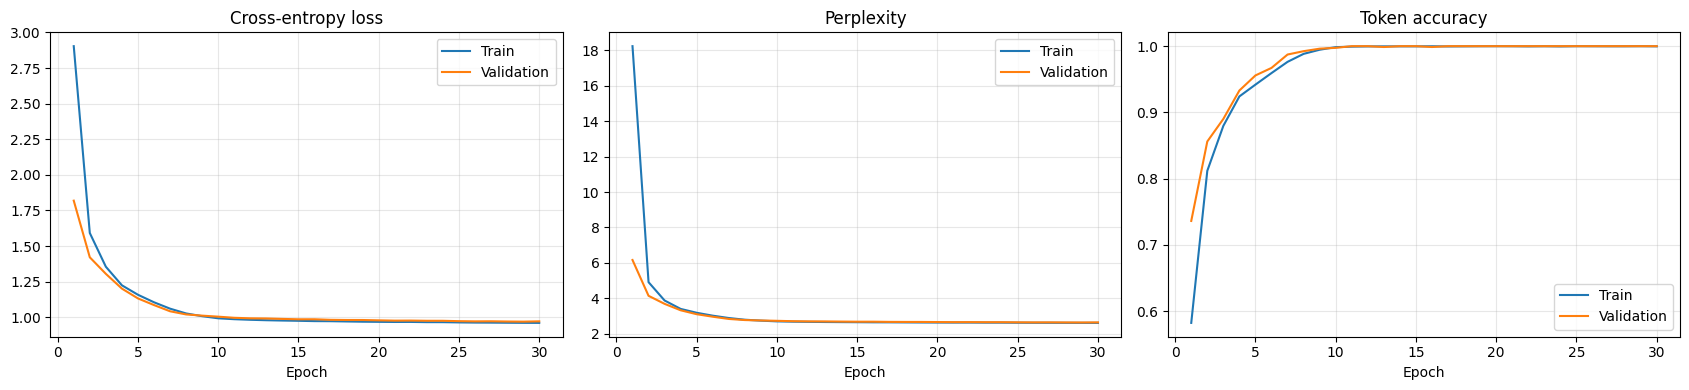

Plot saved: /content/drive/MyDrive/Transformer/transformer_22m/training_curves.png


In [20]:
history_frame = pd.DataFrame(history)

figure, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(history_frame["epoch"], history_frame["train_loss"], label="Train")
axes[0].plot(history_frame["epoch"], history_frame["validation_loss"], label="Validation")
axes[0].set_title("Cross-entropy loss")

axes[1].plot(history_frame["epoch"], history_frame["train_perplexity"], label="Train")
axes[1].plot(history_frame["epoch"], history_frame["validation_perplexity"], label="Validation")
axes[1].set_title("Perplexity")

axes[2].plot(history_frame["epoch"], history_frame["train_token_accuracy"], label="Train")
axes[2].plot(history_frame["epoch"], history_frame["validation_token_accuracy"], label="Validation")
axes[2].set_title("Token accuracy")

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.3)
    axis.legend()

plt.tight_layout()
plot_path = output_dir / "training_curves.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Plot saved:", plot_path)

## — Reload the best checkpoint

Restores the best validation checkpoint before final testing and translation generation.

> Checkpointing preserves model states so training can be resumed and the best-performing version can be used later.

In [21]:
checkpoint = torch.load(
    trainer.best_checkpoint_path,
    map_location=device,
    weights_only=False,
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded epoch:", checkpoint["epoch"])
print("Best validation metrics:", checkpoint["validation_metrics"])

Loaded epoch: 29
Best validation metrics: {'loss': 0.9695817995252032, 'perplexity': 2.6368415003738224, 'token_accuracy': 1.0}


## — Greedy translation and decoding

Generates Bangla tokens autoregressively, stopping when every sentence produces EOS or reaches the maximum length.

> This cell prepares one part of the Transformer pipeline and connects it to the next stage of the model.

In [23]:
class GreedyTranslator:
    def __init__(self, model, config, id_to_token, device):
        self.model = model
        self.config = config
        self.id_to_token = id_to_token
        self.device = device

    @torch.no_grad()
    def generate(self, source_ids):
        self.model.eval()
        source_ids = source_ids.to(self.device)
        encoder_output, source_mask = self.model.encode_source(source_ids)

        batch_size = source_ids.shape[0]
        generated = torch.full(
            (batch_size, 1),
            self.config.beginning_id,
            dtype=torch.long,
            device=self.device,
        )
        finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

        for _ in range(self.config.max_sequence_length - 1):
            logits = self.model.decode_target(
                generated,
                encoder_output,
                source_mask,
            )
            next_ids = logits[:, -1].argmax(dim=-1)
            next_ids = torch.where(
                finished,
                torch.full_like(next_ids, self.config.padding_id),
                next_ids,
            )
            generated = torch.cat([generated, next_ids.unsqueeze(1)], dim=1)
            finished = finished | next_ids.eq(self.config.end_id)

            if bool(finished.all()):
                break

        return generated.cpu()

    def clean_ids(self, token_ids):
        cleaned = []
        for token_id in token_ids:
            token_id = int(token_id)
            if token_id == self.config.end_id:
                break
            if token_id not in {
                self.config.padding_id,
                self.config.beginning_id,
            }:
                cleaned.append(token_id)
        return cleaned

    def decode(self, token_ids):
        tokens = [self.id_to_token[token_id] for token_id in self.clean_ids(token_ids)]
        text = " ".join(tokens)
        text = re.sub(r"\s+([.,!?;:।)\]}])", r"\1", text)
        text = re.sub(r"([(\[{])\s+", r"\1", text)
        return text


translator = GreedyTranslator(
    model,
    config,
    bangla_id_to_token,
    device,
)

## Plotting Heatmap for a single Sequence Attention of Machine Translation

> Attention lets each token compare itself with other tokens and focus more strongly on the parts of the sequence that are most relevant.

In [36]:
import os
import glob
import subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


subprocess.run(
    [
        "apt-get",
        "update",
        "-qq",
    ],
    check=False,
)

subprocess.run(
    [
        "apt-get",
        "install",
        "-y",
        "fonts-noto-core",
        "fonts-noto-extra",
    ],
    check=False,
)

# 2. Refresh Matplotlib font cache


fm._load_fontmanager(
    try_read_cache=False
)


# 3. Search font files directly

candidate_patterns = [
    "/usr/share/fonts/**/*Bengali*.ttf",
    "/usr/share/fonts/**/*Bengali*.otf",
    "/usr/share/fonts/**/*NotoSansBengali*.ttf",
    "/usr/share/fonts/**/*NotoSerifBengali*.ttf",
]


font_candidates = []

for pattern in candidate_patterns:
    font_candidates.extend(
        glob.glob(
            pattern,
            recursive=True
        )
    )


font_candidates = sorted(
    set(font_candidates)
)


print("Bangla font candidates found:")

for path in font_candidates[:10]:
    print(path)


if not font_candidates:
    raise RuntimeError(
        "No Bengali font file was found in Colab."
    )


bangla_font_path = font_candidates[0]


bangla_font = fm.FontProperties(
    fname=bangla_font_path
)


print(
    "\n Using Bangla font:",
    bangla_font_path
)

Bangla font candidates found:
/usr/share/fonts/truetype/noto/NotoSansBengali-Black.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-Bold.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-Condensed.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-ExtraBold.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-ExtraCondensed.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-ExtraLight.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-Light.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-Medium.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf
/usr/share/fonts/truetype/noto/NotoSansBengali-SemiBold.ttf

✓ Using Bangla font: /usr/share/fonts/truetype/noto/NotoSansBengali-Black.ttf


## Deep color grading: high attention = deep color

> Attention lets each token compare itself with other tokens and focus more strongly on the parts of the sequence that are most relevant.

In [44]:
import random
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


@torch.no_grad()
def get_cross_attention_heatmap(
    model,
    translator,
    dataloader,
    english_id_to_token,
    bangla_id_to_token,
    device,
):
    model.eval()

    # --------------------------------------------------------
    # 1. Choose a random batch and random sample
    # --------------------------------------------------------
    random_batch_index = random.randrange(len(dataloader))

    batch = None
    for batch_index, current_batch in enumerate(dataloader):
        if batch_index == random_batch_index:
            batch = current_batch
            break

    sample_index = random.randrange(
        batch["source_ids"].shape[0]
    )

    source_ids = (
        batch["source_ids"][sample_index]
        .unsqueeze(0)
        .to(device)
    )

    # --------------------------------------------------------
    # 2. Remove PAD tokens from English source
    # --------------------------------------------------------
    source_clean_ids = [
        int(token_id)
        for token_id in source_ids[0].cpu()
        if int(token_id) != config.padding_id
    ]

    source_tokens = [
        english_id_to_token[token_id]
        for token_id in source_clean_ids
    ]

    # --------------------------------------------------------
    # 3. Generate Bangla translation
    # --------------------------------------------------------
    generated_ids = translator.generate(source_ids).to(device)

    generated_clean_ids = [
        int(token_id)
        for token_id in generated_ids[0].cpu()
        if int(token_id) not in {
            config.padding_id,
            config.beginning_id,
        }
    ]

    # Keep tokens up to EOS
    if config.end_id in generated_clean_ids:
        eos_position = generated_clean_ids.index(config.end_id)
        generated_clean_ids = generated_clean_ids[:eos_position + 1]

    target_tokens = [
        bangla_id_to_token[token_id]
        for token_id in generated_clean_ids
    ]

    # --------------------------------------------------------
    # 4. Prepare decoder input
    # --------------------------------------------------------
    decoder_ids = torch.tensor(
        [[config.beginning_id] + generated_clean_ids],
        dtype=torch.long,
        device=device,
    )

    decoder_input = decoder_ids[:, :-1]

    # --------------------------------------------------------
    # 5. Encoder forward pass
    # --------------------------------------------------------
    encoder_output, source_mask = model.encode_source(source_ids)

    # --------------------------------------------------------
    # 6. Decoder forward pass manually
    # --------------------------------------------------------
    target_mask = model.create_target_mask(decoder_input)

    hidden_states = model.target_position(
        model.target_embedding(decoder_input)
    )

    decoder_layers = model.decoder.layers

    for layer_index, layer in enumerate(decoder_layers):

        # ----------------------------
        # Self-attention
        # ----------------------------
        normalized = layer.self_attention_norm(hidden_states)

        self_attended = layer.self_attention(
            normalized,
            normalized,
            normalized,
            target_mask,
        )

        hidden_states = hidden_states + layer.dropout(self_attended)

        # ----------------------------
        # Cross-attention
        # ----------------------------
        normalized = layer.cross_attention_norm(hidden_states)

        if layer_index < len(decoder_layers) - 1:
            cross_attended = layer.cross_attention(
                normalized,
                encoder_output,
                encoder_output,
                source_mask,
            )

        else:
            # Extract final-layer cross-attention weights
            attention = layer.cross_attention

            queries = attention._split_heads(
                attention.query_projection(normalized)
            )

            keys = attention._split_heads(
                attention.key_projection(encoder_output)
            )

            values = attention._split_heads(
                attention.value_projection(encoder_output)
            )

            scores = torch.matmul(
                queries,
                keys.transpose(-2, -1),
            )

            scores = scores / math.sqrt(attention.head_dimension)

            scores = scores.masked_fill(
                ~source_mask,
                torch.finfo(scores.dtype).min,
            )

            attention_weights = F.softmax(scores, dim=-1)

            cross_attended = torch.matmul(
                attention_weights,
                values,
            )

            batch_size, _, query_length, _ = cross_attended.shape

            cross_attended = (
                cross_attended
                .transpose(1, 2)
                .contiguous()
                .view(
                    batch_size,
                    query_length,
                    attention.model_dimension,
                )
            )

            cross_attended = attention.output_projection(cross_attended)

        hidden_states = hidden_states + layer.dropout(cross_attended)

        # ----------------------------
        # Feed-forward
        # ----------------------------
        normalized = layer.feedforward_norm(hidden_states)

        hidden_states = hidden_states + layer.dropout(
            layer.feed_forward(normalized)
        )

    # --------------------------------------------------------
    # 7. Average attention across heads
    # --------------------------------------------------------
    attention_map = (
        attention_weights[0]
        .mean(dim=0)
        .detach()
        .float()
        .cpu()
    )

    source_length = len(source_tokens)

    attention_map = attention_map[
        :len(target_tokens),
        :source_length
    ]

    # --------------------------------------------------------
    # 8. Print texts
    # --------------------------------------------------------
    source_text = " ".join(source_tokens)

    translated_text = translator.decode(
        generated_ids[0].cpu()
    )

    print("\n" + "=" * 70)
    print("English sentence:")
    print(source_text)

    print("\nGenerated Bangla:")
    print(translated_text)

    print("\nAttention map shape:", tuple(attention_map.shape))
    print("=" * 70)

    # --------------------------------------------------------
    # 9. Plot heatmap
    # --------------------------------------------------------
    figure_width = max(10, len(source_tokens) * 0.9)
    figure_height = max(7, len(target_tokens) * 0.7)

    fig, ax = plt.subplots(
        figsize=(figure_width, figure_height)
    )

    # Deep color for high attention, very light for low attention
    image = ax.imshow(
        attention_map.numpy(),
        aspect="auto",
        cmap="Blues",              # deep blue = high attention
        interpolation="nearest",
        vmin=0.0,
        vmax=max(float(attention_map.max()), 1e-8),
    )

    # Colorbar
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(
        "Cross-Attention Weight",
        fontsize=11,
    )

    # X-axis
    ax.set_xticks(range(len(source_tokens)))
    ax.set_xticklabels(
        source_tokens,
        rotation=45,
        ha="right",
        fontsize=11,
    )

    # Y-axis
    ax.set_yticks(range(len(target_tokens)))

    if "bangla_font" in globals():
        ax.set_yticklabels(
            target_tokens,
            fontproperties=bangla_font,
            fontsize=13,
        )
    else:
        ax.set_yticklabels(
            target_tokens,
            fontsize=13,
        )

    # Labels
    ax.set_xlabel(
        "English Source Tokens",
        fontsize=12,
    )

    ax.set_ylabel(
        "Generated Bangla Tokens",
        fontsize=12,
    )

    # Title
    ax.set_title(
        "English → Bangla Cross-Attention Heatmap\n"
        "Last Decoder Layer — Mean Across All Attention Heads",
        fontsize=14,
        pad=15,
    )

    # Optional grid lines for clearer cell boundaries
    ax.set_xticks(
        [x - 0.5 for x in range(1, len(source_tokens))],
        minor=True,
    )
    ax.set_yticks(
        [y - 0.5 for y in range(1, len(target_tokens))],
        minor=True,
    )

    ax.grid(
        which="minor",
        color="gray",
        linestyle="-",
        linewidth=0.4,
        alpha=0.4,
    )

    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1400/3371382628.py:322: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_1400/3371382628.py:322: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_1400/3371382628.py:322: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_1400/3371382628.py:322: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()
/tmp/ipykernel_1400/3371382628.py:322: UserWarning: Glyph 115 (s) missing from font(s) Noto Sans Bengali.
  plt.tight_layout()



English sentence:
<bos> mina reads a magazine every evening . <eos>

Generated Bangla:
মিনা প্রতিদিন সন্ধ্যায় একটি সাময়িকী পড়ে।

Attention map shape: (8, 9)


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 115 (s) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


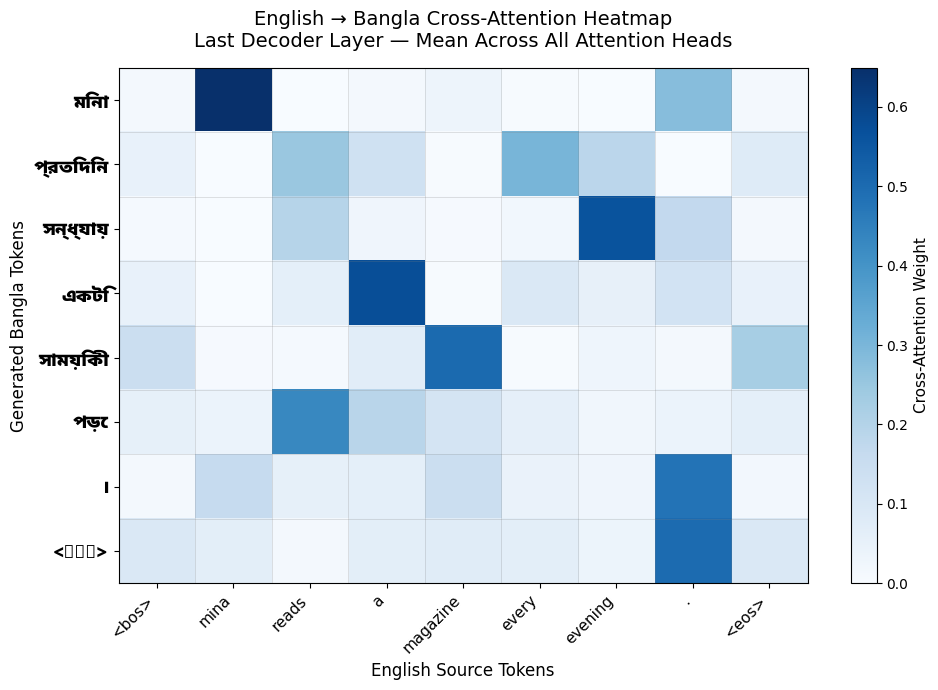

In [45]:
# Run on RANDOM TEST sentence
get_cross_attention_heatmap(
    model=model,
    translator=translator,
    dataloader=dataloaders["test"],
    english_id_to_token=english_id_to_token,
    bangla_id_to_token=bangla_id_to_token,
    device=device,
)

## — BLEU-4 and exact-match metrics

Implements corpus BLEU-4 with clipped n-gram precision and brevity penalty, plus strict sequence exact match.

> Testing evaluates the trained model on held-out data to estimate how well it generalizes beyond the training examples.

In [46]:
def ngram_counts(tokens, n):
    return Counter(
        tuple(tokens[index : index + n])
        for index in range(len(tokens) - n + 1)
    )


def corpus_bleu(references, hypotheses, maximum_n=4):
    clipped = [0] * maximum_n
    totals = [0] * maximum_n
    reference_length = 0
    hypothesis_length = 0

    for reference, hypothesis in zip(references, hypotheses):
        reference_length += len(reference)
        hypothesis_length += len(hypothesis)

        for n in range(1, maximum_n + 1):
            reference_counts = ngram_counts(reference, n)
            hypothesis_counts = ngram_counts(hypothesis, n)
            totals[n - 1] += sum(hypothesis_counts.values())
            clipped[n - 1] += sum(
                min(count, reference_counts[gram])
                for gram, count in hypothesis_counts.items()
            )

    precisions = [
        (clipped_count + 1.0) / (total_count + 1.0)
        for clipped_count, total_count in zip(clipped, totals)
    ]
    geometric_mean = math.exp(
        sum(math.log(precision) for precision in precisions) / maximum_n
    )

    if hypothesis_length == 0:
        return 0.0
    brevity_penalty = (
        1.0
        if hypothesis_length >= reference_length
        else math.exp(1.0 - reference_length / hypothesis_length)
    )
    return 100.0 * brevity_penalty * geometric_mean


def exact_match_rate(references, hypotheses):
    matches = sum(
        int(reference == hypothesis)
        for reference, hypothesis in zip(references, hypotheses)
    )
    return matches / max(len(references), 1)

## — Final test evaluation

Measures teacher-forced test loss/perplexity/accuracy and free-generation BLEU-4/exact match.

> Testing evaluates the trained model on held-out data to estimate how well it generalizes beyond the training examples.

In [47]:
teacher_forced_test_metrics = trainer.evaluate(dataloaders["test"])

reference_sequences = []
hypothesis_sequences = []
translation_rows = []

for batch in dataloaders["test"]:
    generated_batch = translator.generate(batch["source_ids"])

    for index in range(generated_batch.shape[0]):
        reference_ids = translator.clean_ids(batch["target_ids"][index].tolist())
        hypothesis_ids = translator.clean_ids(generated_batch[index].tolist())
        reference_sequences.append(reference_ids)
        hypothesis_sequences.append(hypothesis_ids)
        translation_rows.append(
            {
                "english": batch["source_text"][index],
                "reference_bangla": batch["target_text"][index],
                "generated_bangla": translator.decode(generated_batch[index].tolist()),
            }
        )

test_metrics = {
    **teacher_forced_test_metrics,
    "bleu_4": corpus_bleu(reference_sequences, hypothesis_sequences),
    "exact_match": exact_match_rate(reference_sequences, hypothesis_sequences),
    "parameter_count": trainable_parameters,
    "best_epoch": checkpoint["epoch"],
}

print(json.dumps(test_metrics, indent=2))

{
  "loss": 0.9689480791158993,
  "perplexity": 2.6351710094669327,
  "token_accuracy": 1.0,
  "bleu_4": 100.0,
  "exact_match": 1.0,
  "parameter_count": 22566879,
  "best_epoch": 29
}


## — Save metrics and translations

Writes final metrics, architecture settings, and generated examples to Google Drive.

> Testing evaluates the trained model on held-out data to estimate how well it generalizes beyond the training examples.

In [48]:
metrics_path = output_dir / "test_metrics.json"
metrics_path.write_text(
    json.dumps(test_metrics, indent=2),
    encoding="utf-8",
)

translations_frame = pd.DataFrame(translation_rows)
translations_path = output_dir / "test_translations.csv"
translations_frame.to_csv(translations_path, index=False, encoding="utf-8-sig")

architecture_path = output_dir / "architecture.json"
architecture_path.write_text(
    json.dumps(
        {
            "config": asdict(config),
            "trainable_parameters": trainable_parameters,
            "source_vocabulary_size": len(english_id_to_token),
            "target_vocabulary_size": len(bangla_id_to_token),
        },
        indent=2,
    ),
    encoding="utf-8",
)

print("Metrics:", metrics_path)
print("Translations:", translations_path)
print("Architecture:", architecture_path)

Metrics: /content/drive/MyDrive/Transformer/transformer_22m/test_metrics.json
Translations: /content/drive/MyDrive/Transformer/transformer_22m/test_translations.csv
Architecture: /content/drive/MyDrive/Transformer/transformer_22m/architecture.json


## — Inspect sample translations

Displays a small qualitative sample beside the quantitative test metrics.

> This cell prepares one part of the Transformer pipeline and connects it to the next stage of the model.

In [49]:
pd.set_option("display.max_colwidth", 120)
translations_frame.head(15)

,english,reference_bangla,generated_bangla
0,"every evening, the family plans the next week.",প্রতিদিন সন্ধ্যায় পরিবারটি পরের সপ্তাহের পরিকল্পনা করে।,প্রতিদিন সন্ধ্যায় পরিবারটি পরের সপ্তাহের পরিকল্পনা করে।
1,There is a classroom in the whiteboard.,শ্রেণিকক্ষে একটি সাদা বোর্ড আছে।,শ্রেণিকক্ষে একটি সাদা বোর্ড আছে।
2,There is a laboratory in the fan.,গবেষণাগারে একটি পাখা আছে।,গবেষণাগারে একটি পাখা আছে।
3,The traveler goes to Sylhet by bicycle.,ভ্রমণকারী সিলেটে সাইকেলে যায়।,ভ্রমণকারী সিলেটে সাইকেলে যায়।
4,There is a library in the whiteboard.,গ্রন্থাগারে একটি সাদা বোর্ড আছে।,গ্রন্থাগারে একটি সাদা বোর্ড আছে।
5,"If it rains, we will visit the market.","যদি বৃষ্টি হয়, আমরা বাজারে যাব।","যদি বৃষ্টি হয়, আমরা বাজারে যাব।"
6,My friend will attend the meeting next Monday.,আমার বন্ধু আগামী সোমবার সভায় অংশ নেবে।,আমার বন্ধু আগামী সোমবার সভায় অংশ নেবে।
7,The pharmacist explained routine checkups to the patient.,ফার্মাসিস্ট রোগীকে নিয়মিত স্বাস্থ্য পরীক্ষা সম্পর্কে বুঝিয়ে বলেছেন।,ফার্মাসিস্ট রোগীকে নিয়মিত স্বাস্থ্য পরীক্ষা সম্পর্কে বুঝিয়ে বলেছেন।
8,We measured inference time for the second experiment.,আমরা দ্বিতীয় পরীক্ষার ইনফারেন্স সময় পরিমাপ করেছি।,আমরা দ্বিতীয় পরীক্ষার ইনফারেন্স সময় পরিমাপ করেছি।
9,We measured accuracy for the test set.,আমরা টেস্ট সেটের নির্ভুলতা পরিমাপ করেছি।,আমরা টেস্ট সেটের নির্ভুলতা পরিমাপ করেছি।
